# XGBoost model — mortgage approval (2025 HMDA LAR)

Trains the XGBoost model: feature selection, imbalance handling, Optuna tuning, final fit,
calibration, and the model's statistical and economic performance.

**Out of scope here** (covered in the *ISF Evaluation Methodology* doc and run in separate notebooks
for all three models): interpretability (SHAP, XPER, permutation importance), stability
(bootstrap feature-importance distance) and fairness (group tests, Fairlearn, FPDP, TOST, mitigation).
This notebook only produces the model those steps consume.

**Inputs:** `data/processed/{train,val,test}.parquet` from `data_cleaning.ipynb` (same fixed split
as the rest of the team).

**Outputs** (all in `models/`, git-ignored — regenerate by running this notebook):
- `xgboost_model.joblib` — fitted booster + category encodings + calibrator
- `xgboost_params.json` — tuned hyper-parameters with a fixed `n_estimators`, read by
  `src/xgboost_model.fit()` so bootstrap refits in the stability step reuse the same model spec
- `xgboost_results.json` — headline metrics for the cross-model results table

**Shared interface.** The model lives in `src/xgboost_model.py` and exposes
`fit(X_train, y_train) -> model` and `predict_proba(model, X) -> (n, 2)`. `X` is the *cleaned*
DataFrame — feature selection, encoding and calibration all happen inside. For the gain-based
importance vector in the stability step, the underlying XGBoost model is `model.booster`
(`model.booster.get_booster().get_score(importance_type="gain")`).

**Runtime** (10-core laptop, rough): Optuna tuning is capped at `TUNE_TIMEOUT_MIN` (45 min), final fit
~15–30 min on the full 6.4M-row train set, the rest a few minutes. Lower `N_TRIALS`,
`TUNE_TIMEOUT_MIN` or `TUNE_SAMPLE_N`, or raise `FINAL_LEARNING_RATE`, for a faster first pass.

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import pyarrow.parquet as pq
import xgboost as xgb
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score, brier_score_loss, log_loss, precision_recall_curve, roc_auc_score,
    roc_curve,
)

sys.path.insert(0, str(Path("../src").resolve()))
import xgboost_model as xm

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

# Tuning (Optuna)
TUNE_SAMPLE_N = 1_000_000      # train rows per tuning trial
TUNE_VAL_N = 300_000           # val rows used for early stopping / scoring during tuning
N_TRIALS = 30
TUNE_TIMEOUT_MIN = 45          # hard cap on tuning wall-clock time; the study stops at whichever comes first
TUNE_LEARNING_RATE = 0.1       # fixed while searching tree-shape params, lowered for the final fit
FINAL_LEARNING_RATE = 0.05

# Imbalance — see section 2 for why the default is no re-weighting
SCALE_POS_WEIGHT = 1.0

# Calibration: "isotonic", "platt" or "none"
CALIBRATION = "isotonic"

## 1. Feature selection

The model uses 31 features (8 numeric, 1 engineered, 22 categorical).

**Already deleted upstream** (not in the cleaned dataset at all):
- raw applicant / co-applicant demographics: `applicant_race_1`, `applicant_ethnicity_1`,
  `applicant_sex`, `co_applicant_race_1`, `co_applicant_ethnicity_1`, `co_applicant_sex`,
  `applicant_age_above_62`, `co_applicant_age_above_62`, and the `*_observed` collection-method flags
- leakage: `hoepa_status`, `preapproval`, `discount_points`, `lender_credits`

**Still in the dataset but never used as inputs:**

*Protected by law (16 columns): kept for the fairness evaluation only.* US fair-lending law
(ECOA / Fair Housing Act) forbids basing credit decisions on these, directly or through geography:
- demographics: `derived_race`, `derived_ethnicity`, `derived_sex`, `applicant_age`, `co_applicant_age`
- location identifiers: `census_tract`, `county_code`, `state_code`, `derived_msa_md` (with ~80k
  tracts the model could learn *which neighbourhoods get denied*, i.e. redlining)
- tract / area context: `tract_minority_population_percent`, `tract_to_msa_income_percentage`,
  `ffiec_msa_md_median_family_income`, `tract_population`, `tract_owner_occupied_units`,
  `tract_one_to_four_family_homes`, `tract_median_age_of_housing_units`

*Leakage:* `initially_payable_to_institution`. HMDA requires code 3 ("not applicable") for any loan
not originated. In the data, code 3 → 5.9% approved vs ~80% otherwise, so it partly encodes the
decision.

*Proxy risk:* `lei` (lender identifier, ~4.5k values). Lender choice correlates with race, and the
model could memorise lenders instead of learning applicant risk.

The model only loads its own feature columns (`xm.RAW_COLUMNS`), so the excluded columns never reach
training, and `src/xgboost_model.py` asserts that no excluded column is in the feature list.

**Engineered:** `loan_to_income` = `loan_amount` / (`income` × 1000), a standard underwriting ratio
that trees can only approximate with many splits. Everything else is left to the model (no scaling,
no bins, no hand-made interactions). Categoricals use XGBoost's native categorical support;
HMDA's `1111` ("exempt") code is kept as its own category, and missing values are left as NaN so
XGBoost learns the default split direction.

In [2]:
print(f"{len(xm.FEATURES)} features: {len(xm.NUMERIC_FEATURES)} numeric, "
      f"{len(xm.ENGINEERED_FEATURES)} engineered, {len(xm.CATEGORICAL_FEATURES)} categorical")
for group, cols in xm.EXCLUDED.items():
    print(f"\nexcluded — {group} ({len(cols)}): {cols}")

32 features: 9 numeric, 1 engineered, 22 categorical

excluded — leakage (1): ['initially_payable_to_institution']

excluded — race_proxy (1): ['lei']


In [3]:
missing = set(xm.RAW_COLUMNS + ["target"]) - set(pq.read_schema(DATA_DIR / "train.parquet").names)
assert not missing, f"model columns missing from the dataset: {sorted(missing)}"
LOAD_COLS = xm.RAW_COLUMNS + ["target"]

t0 = time.time()
train = pd.read_parquet(DATA_DIR / "train.parquet", columns=LOAD_COLS)
val = pd.read_parquet(DATA_DIR / "val.parquet", columns=LOAD_COLS)
test = pd.read_parquet(DATA_DIR / "test.parquet", columns=LOAD_COLS)
y_train, y_val, y_test = (d["target"].to_numpy() for d in (train, val, test))
print(f"loaded in {time.time() - t0:.0f}s — train {len(train):,}, val {len(val):,}, test {len(test):,}")

loaded in 1s — train 6,393,228, val 1,369,943, test 1,369,785


## 2. Base rate and imbalance

`target = 1` is *approval*, so the minority class is denial (~22%). That's imbalanced but not rare,
so:
- **Primary metric: ROC-AUC.** We also report PR-AUC for the *denial* class, which is more
  sensitive to how well the minority class is ranked than PR-AUC on the 78%-majority class.
- **No re-weighting by default (`SCALE_POS_WEIGHT = 1`).** `scale_pos_weight` changes the loss the
  same way resampling does, so it distorts predicted probabilities, which we need calibrated for
  the P&L threshold and the fairness metrics. At 78/22 there's enough signal in both classes, and
  the cost asymmetry is handled where it belongs — in the decision threshold (section 7). Set it
  to `n_neg / n_pos` below if the team wants a re-weighted variant for comparison.

In [4]:
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name}: approval rate {y.mean():.3f}  (denial {1 - y.mean():.3f})")
n_pos, n_neg = y_train.sum(), len(y_train) - y_train.sum()
print(f"\nn_neg / n_pos = {n_neg / n_pos:.3f}  — SCALE_POS_WEIGHT in use: {SCALE_POS_WEIGHT}")

train: approval rate 0.775  (denial 0.225)
val: approval rate 0.775  (denial 0.225)
test: approval rate 0.775  (denial 0.225)

n_neg / n_pos = 0.290  — SCALE_POS_WEIGHT in use: 1.0


## 3. Hyper-parameter tuning (Optuna)

Bayesian search with [Optuna](https://optuna.org) over tree-shape and regularisation parameters:
`max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`.

- **Sampler — TPE** (Tree-structured Parzen Estimator). Unlike random search, it learns from
  completed trials and proposes new ones where good results have clustered, so a fixed budget of
  trials reaches better parameters.
- **Pruner — median.** Every 10 boosting rounds a trial reports its validation AUC. If it's below
  the median of earlier trials at the same round, it's stopped early (never before round 100, and
  never during the first 5 trials, which set the baseline). This spends less time on bad combinations.
- **Budget:** `N_TRIALS` or `TUNE_TIMEOUT_MIN`, whichever comes first.

Each trial trains on a 1M-row train sample with early stopping on a 300k-row val sample, which picks
`n_estimators` per trial. The fixed val split replaces k-fold CV: at this size a 300k holdout gives a
very tight AUC estimate, and CV would multiply the cost by k for no real gain. `learning_rate` is fixed
at 0.1 while searching and lowered for the final fit (section 4). That's the standard approach: a lower
rate with more trees gives a small gain but doesn't change which tree shapes work best.

Pruning uses a small custom XGBoost callback rather than `optuna-integration`, so no extra package is
needed.

In [5]:
cat_dtypes = xm.learn_cat_dtypes(train)
tune_idx = np.random.default_rng(RANDOM_STATE).choice(len(train), TUNE_SAMPLE_N, replace=False)
tval_idx = np.random.default_rng(RANDOM_STATE).choice(len(val), TUNE_VAL_N, replace=False)
X_tune, y_tune = xm.build_features(train.iloc[tune_idx], cat_dtypes), y_train[tune_idx]
X_tval, y_tval = xm.build_features(val.iloc[tval_idx], cat_dtypes), y_val[tval_idx]


class OptunaPruningCallback(xgb.callback.TrainingCallback):
    """Report val AUC to Optuna every `every` rounds and abort the fit if the trial is pruned."""

    def __init__(self, trial, every=10):
        self.trial, self.every = trial, every

    def after_iteration(self, model, epoch, evals_log):
        if epoch % self.every == 0:
            self.trial.report(evals_log["validation_0"]["auc"][-1], step=epoch)
            if self.trial.should_prune():
                raise optuna.TrialPruned()
        return False


def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 100, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 100, log=True),
        "n_estimators": 3000,
        "learning_rate": TUNE_LEARNING_RATE,
        "scale_pos_weight": SCALE_POS_WEIGHT,
    }
    t0 = time.time()
    clf = xm.make_classifier(params, early_stopping_rounds=50)
    clf.set_params(callbacks=[OptunaPruningCallback(trial)])
    clf.fit(X_tune, y_tune, eval_set=[(X_tval, y_tval)], verbose=False)
    trial.set_user_attr("best_iteration", int(clf.best_iteration))
    trial.set_user_attr("seconds", round(time.time() - t0, 1))
    return clf.best_score


study = optuna.create_study(
    study_name="xgboost_mortgage",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=100, interval_steps=10),
)
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, timeout=TUNE_TIMEOUT_MIN * 60)

states = pd.Series([t.state.name for t in study.trials]).value_counts()
print(f"\ntuning: {time.time() - t0:.0f}s — {dict(states)}")

trials = (
    study.trials_dataframe(attrs=("number", "value", "params", "user_attrs", "state"))
    .rename(columns={"value": "val_auc"})
    .sort_values("val_auc", ascending=False)
)
trials.head(10)

[I 2026-09-24 17:18:09,442] A new study created in memory with name: xgboost_mortgage
[I 2026-09-24 17:20:12,662] Trial 0 finished with value: 0.8931978887362731 and parameters: {'max_depth': 6, 'min_child_weight': 79.69454818643933, 'subsample': 0.8927975767245621, 'colsample_bytree': 0.7993292420985183, 'reg_alpha': 0.004207988669606638, 'reg_lambda': 0.042070539502879374}. Best is trial 0 with value: 0.8931978887362731.
[I 2026-09-24 17:22:41,351] Trial 1 finished with value: 0.8903714041653131 and parameters: {'max_depth': 4, 'min_child_weight': 53.99484409787433, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8540362888980227, 'reg_alpha': 0.0012087541473056963, 'reg_lambda': 75.79479953348003}. Best is trial 0 with value: 0.8931978887362731.
[I 2026-09-24 17:23:32,994] Trial 2 finished with value: 0.8934469260431451 and parameters: {'max_depth': 9, 'min_child_weight': 2.65875439832727, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 0


tuning: 1334s — {'COMPLETE': np.int64(19), 'PRUNED': np.int64(11)}


,number,val_auc,params_colsample_bytree,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,user_attrs_best_iteration,user_attrs_seconds,state
19,19,0.894614,0.723852,9,4.939619,0.768918,0.011954,0.908981,604.0,48.5,COMPLETE
22,22,0.894564,0.655474,9,5.537699,0.064988,0.023158,0.879768,602.0,49.6,COMPLETE
14,14,0.894527,0.671400,9,5.532052,1.154530,0.367095,0.917057,602.0,50.8,COMPLETE
16,16,0.894511,0.653056,9,4.044759,0.066220,0.040798,0.927697,573.0,49.9,COMPLETE
21,21,0.894492,0.765618,9,4.745885,0.564870,0.083594,0.913979,612.0,50.0,COMPLETE
18,18,0.894434,0.665328,9,1.135558,1.430566,0.042009,0.940806,603.0,49.9,COMPLETE
26,26,0.894353,0.626934,10,23.737457,0.846580,0.010653,0.898328,601.0,52.5,COMPLETE
23,23,0.894296,0.705240,10,11.314601,0.567069,0.017499,0.875499,543.0,48.5,COMPLETE
27,27,0.894207,0.704735,9,2.911661,0.033620,0.024795,0.812469,542.0,46.3,COMPLETE
3,3,0.894182,0.569747,7,3.823475,0.014743,0.292043,0.844741,1325.0,95.2,COMPLETE


best trial #19: val AUC 0.8946, 604 trees
params: {'max_depth': 9, 'min_child_weight': 4.9396, 'subsample': 0.909, 'colsample_bytree': 0.7239, 'reg_alpha': 0.7689, 'reg_lambda': 0.012}
val AUC spread across completed trials: 0.8904 – 0.8946


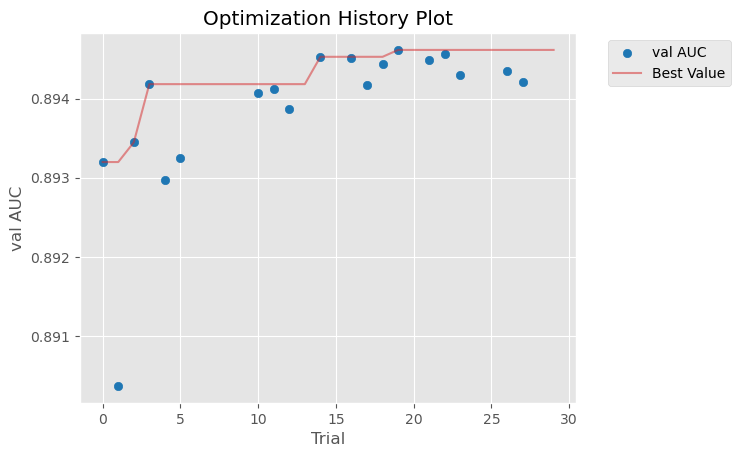

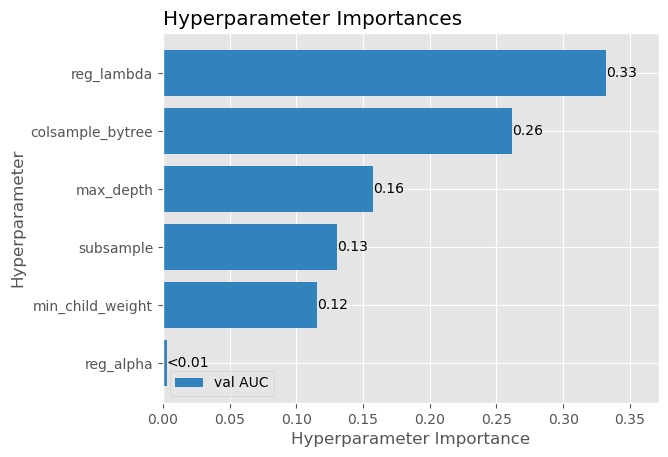

In [6]:
tuned_params = dict(study.best_params)
completed = trials[trials.state == "COMPLETE"]
print(f"best trial #{study.best_trial.number}: val AUC {study.best_value:.4f}, "
      f"{study.best_trial.user_attrs['best_iteration']} trees")
print("params:", {k: round(v, 4) if isinstance(v, float) else v for k, v in tuned_params.items()})
print(f"val AUC spread across completed trials: {completed.val_auc.min():.4f} – {completed.val_auc.max():.4f}")

# Optuna's matplotlib plots are flagged experimental; they're fine for reporting
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)
optuna.visualization.matplotlib.plot_optimization_history(study, target_name="val AUC")
optuna.visualization.matplotlib.plot_param_importances(study, target_name="val AUC")
plt.show()

## 4. Final model

`xm.fit()` — the same function the stability harness will call — on the full train set with the
tuned parameters and the lower learning rate. It holds out 10% of train (stratified) to fit the
calibrator, trains the booster on the other 90%, and here uses the val set for early stopping to
fix the number of trees. That number is written to `xgboost_params.json`, so bootstrap refits train
the same number of trees without needing an eval set.

In [7]:
final_params = {**tuned_params, "learning_rate": FINAL_LEARNING_RATE, "n_estimators": 5000,
                "scale_pos_weight": SCALE_POS_WEIGHT}

t0 = time.time()
model = xm.fit(train, y_train, params=final_params, calibration=CALIBRATION, eval_set=(val, y_val))
print(f"final fit: {time.time() - t0:.0f}s, {model.booster.best_iteration + 1} trees, "
      f"val AUC {model.booster.best_score:.4f}")

saved_params = {**final_params, "n_estimators": int(model.booster.best_iteration + 1)}
xm.PARAMS_PATH.write_text(json.dumps(saved_params, indent=2))
print(f"wrote {xm.PARAMS_PATH}")

[0]	validation_0-auc:0.83983
[100]	validation_0-auc:0.88404
[200]	validation_0-auc:0.89081
[300]	validation_0-auc:0.89406
[400]	validation_0-auc:0.89605
[500]	validation_0-auc:0.89735
[600]	validation_0-auc:0.89842
[700]	validation_0-auc:0.89935
[800]	validation_0-auc:0.90022
[900]	validation_0-auc:0.90086
[1000]	validation_0-auc:0.90141
[1100]	validation_0-auc:0.90184
[1200]	validation_0-auc:0.90228
[1300]	validation_0-auc:0.90263
[1400]	validation_0-auc:0.90297
[1500]	validation_0-auc:0.90324
[1600]	validation_0-auc:0.90349
[1700]	validation_0-auc:0.90370
[1800]	validation_0-auc:0.90390
[1900]	validation_0-auc:0.90406
[2000]	validation_0-auc:0.90424
[2100]	validation_0-auc:0.90438
[2200]	validation_0-auc:0.90451
[2300]	validation_0-auc:0.90461
[2400]	validation_0-auc:0.90472
[2500]	validation_0-auc:0.90480
[2600]	validation_0-auc:0.90488
[2700]	validation_0-auc:0.90495
[2800]	validation_0-auc:0.90504
[2900]	validation_0-auc:0.90510
[3000]	validation_0-auc:0.90517
[3100]	validation_0-

## 5. Calibration

Tree ensembles are often mis-calibrated (scores pushed away from 0/1 or bunched up). A reliability
diagram on the **test** set compares raw booster scores with the calibrated ones; the calibrator
was fitted on the 10% train holdout, so test is untouched by both training and calibration.
Isotonic regression is used by default because with ~640k calibration rows it has plenty of data
and makes no shape assumption; Platt scaling (`CALIBRATION = "platt"`) is the fallback if isotonic
looks step-like or over-fitted.

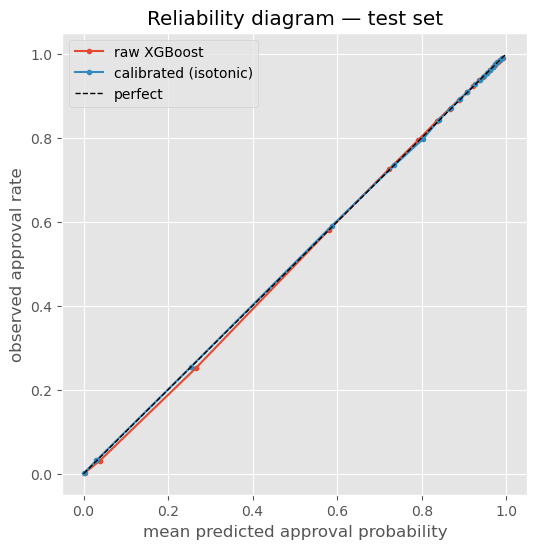

,Brier,log loss,AUC
raw,0.0802,0.2747,0.9066
calibrated,0.0802,0.2747,0.9065


In [8]:
p_test_raw = xm.predict_proba(model, test, calibrated=False)[:, 1]
p_test = xm.predict_proba(model, test)[:, 1]
p_val = xm.predict_proba(model, val)[:, 1]

fig, ax = plt.subplots(figsize=(6, 6))
for label, p in [("raw XGBoost", p_test_raw), (f"calibrated ({CALIBRATION})", p_test)]:
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=20, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", ms=3, label=label)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
ax.set(xlabel="mean predicted approval probability", ylabel="observed approval rate",
       title="Reliability diagram — test set")
ax.legend()
plt.show()

calib_table = pd.DataFrame({
    label: {"Brier": brier_score_loss(y_test, p), "log loss": log_loss(y_test, p),
            "AUC": roc_auc_score(y_test, p)}
    for label, p in [("raw", p_test_raw), ("calibrated", p_test)]
}).T
calib_table.round(4)

## 6. Statistical performance (test set)

ROC-AUC:            0.9065
PR-AUC (approval):  0.9621   (base rate 0.775)
PR-AUC (denial):    0.8299   (base rate 0.225)


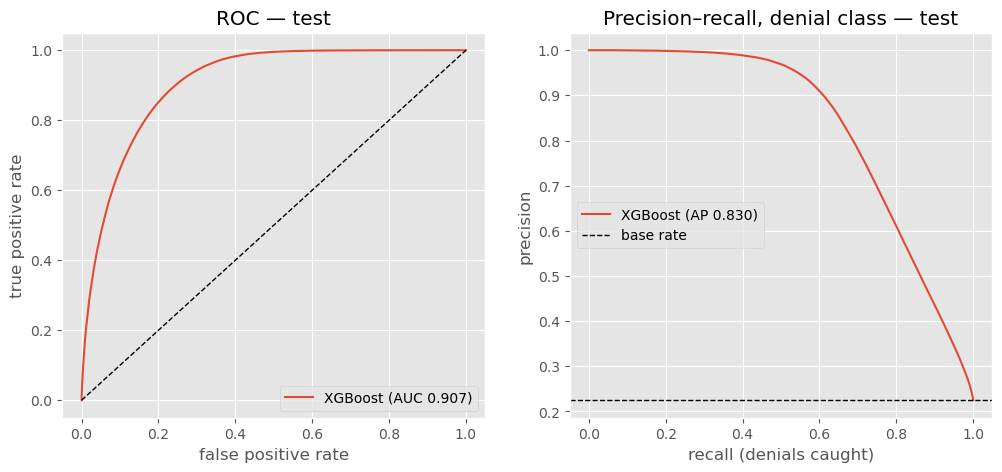

In [9]:
auc = roc_auc_score(y_test, p_test)
pr_auc_approve = average_precision_score(y_test, p_test)
pr_auc_deny = average_precision_score(1 - y_test, 1 - p_test)
print(f"ROC-AUC:            {auc:.4f}")
print(f"PR-AUC (approval):  {pr_auc_approve:.4f}   (base rate {y_test.mean():.3f})")
print(f"PR-AUC (denial):    {pr_auc_deny:.4f}   (base rate {1 - y_test.mean():.3f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fpr, tpr, _ = roc_curve(y_test, p_test)
axes[0].plot(fpr, tpr, label=f"XGBoost (AUC {auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC — test")
axes[0].legend()
prec, rec, _ = precision_recall_curve(1 - y_test, 1 - p_test)
axes[1].plot(rec, prec, label=f"XGBoost (AP {pr_auc_deny:.3f})")
axes[1].axhline(1 - y_test.mean(), color="k", ls="--", lw=1, label="base rate")
axes[1].set(xlabel="recall (denials caught)", ylabel="precision", title="Precision–recall, denial class — test")
axes[1].legend()
plt.show()

## 7. Economic performance

**Framing.** The target is the lender's *decision*, not loan default (HMDA has no repayment data).
So the client is a lender using the model as an automated first-pass underwriter, and the costs are
relative to what full manual underwriting would have decided:

| | actually approved (y=1) | actually denied (y=0) |
|---|---|---|
| **model approves** | + `PROFIT_GOOD_APPROVAL` — loan originated | − `LOSS_BAD_APPROVAL` — a loan underwriting would reject gets through |
| **model denies** | 0 — forgone profit (shows up as the gap to the oracle) | 0 — correct rejection |

⚠️ **The two numbers below are placeholders that the whole team must agree on.** They define the
`team_pnl_fn` and `team_threshold` the methodology doc uses for XPER and the fairness tests, so the
same values must be used for logreg and TabPFN.

With calibrated probabilities, the P&L-optimal rule is to approve when
`p × PROFIT > (1 − p) × LOSS`, i.e. `p > LOSS / (PROFIT + LOSS)`. We check that theoretical
threshold against an empirical sweep on **val** and then report P&L on **test**.

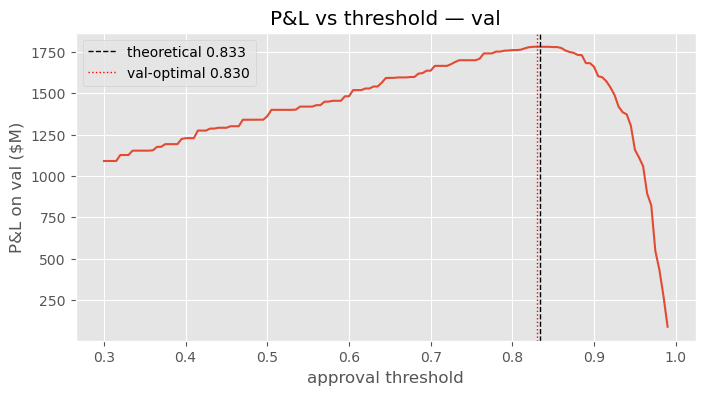

theoretical 0.833 vs val-optimal 0.830 — using 0.833 (a gap here means the calibration is off)


In [10]:
PROFIT_GOOD_APPROVAL = 3_000    # $ net margin on an originated loan — PLACEHOLDER, agree with team
LOSS_BAD_APPROVAL = 15_000      # $ expected loss on approving a should-be-denied loan — PLACEHOLDER


def pnl(y, approve):
    y, approve = np.asarray(y), np.asarray(approve, dtype=bool)
    tp = np.sum(approve & (y == 1))
    fp = np.sum(approve & (y == 0))
    return tp * PROFIT_GOOD_APPROVAL - fp * LOSS_BAD_APPROVAL


theoretical_threshold = LOSS_BAD_APPROVAL / (PROFIT_GOOD_APPROVAL + LOSS_BAD_APPROVAL)
thresholds = np.linspace(0.30, 0.99, 139)
val_pnl = np.array([pnl(y_val, p_val >= t) for t in thresholds])
empirical_threshold = thresholds[val_pnl.argmax()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, val_pnl / 1e6)
ax.axvline(theoretical_threshold, color="k", ls="--", lw=1, label=f"theoretical {theoretical_threshold:.3f}")
ax.axvline(empirical_threshold, color="r", ls=":", lw=1, label=f"val-optimal {empirical_threshold:.3f}")
ax.set(xlabel="approval threshold", ylabel="P&L on val ($M)", title="P&L vs threshold — val")
ax.legend()
plt.show()

DECISION_THRESHOLD = theoretical_threshold
print(f"theoretical {theoretical_threshold:.3f} vs val-optimal {empirical_threshold:.3f} "
      f"— using {DECISION_THRESHOLD:.3f} (a gap here means the calibration is off)")

In [11]:
approve_test = p_test >= DECISION_THRESHOLD
econ = pd.DataFrame({
    "P&L ($M)": {
        "XGBoost": pnl(y_test, approve_test),
        "approve everyone": pnl(y_test, np.ones_like(y_test, dtype=bool)),
        "oracle (perfect underwriting)": pnl(y_test, y_test == 1),
    },
    "approval rate": {
        "XGBoost": approve_test.mean(),
        "approve everyone": 1.0,
        "oracle (perfect underwriting)": y_test.mean(),
    },
})
econ["P&L ($M)"] /= 1e6
pnl_test = pnl(y_test, approve_test)
print(f"XGBoost captures {pnl_test / pnl(y_test, y_test == 1):.1%} of the oracle P&L on test")
econ.round(3)

XGBoost captures 56.3% of the oracle P&L on test


,P&L ($M),approval rate
XGBoost,1793.733,0.675
approve everyone,-1432.737,1.000
oracle (perfect underwriting),3185.673,0.775


## 8. Save artifacts

To load the model elsewhere (SHAP/XPER, stability, fairness notebooks, app), put `src/` on the path
first, because the pickled object refers to the `xgboost_model` module:

```python
import sys; sys.path.insert(0, "src")
import joblib, xgboost_model as xm
model = joblib.load("models/xgboost_model.joblib")
p = xm.predict_proba(model, df)[:, 1]
```

In [12]:
joblib.dump(model, MODELS_DIR / "xgboost_model.joblib")

results = {
    "model": "XGBoost",
    "roc_auc": auc,
    "pr_auc_approval": pr_auc_approve,
    "pr_auc_denial": pr_auc_deny,
    "brier": brier_score_loss(y_test, p_test),
    "decision_threshold": DECISION_THRESHOLD,
    "pnl_test": float(pnl_test),
    "approval_rate_test": float(approve_test.mean()),
    "calibration": CALIBRATION,
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "n_estimators": saved_params["n_estimators"],
}
(MODELS_DIR / "xgboost_results.json").write_text(json.dumps(results, indent=2, default=float))
pd.Series(results)

model                      XGBoost
roc_auc                   0.906522
pr_auc_approval           0.962069
pr_auc_denial             0.829924
brier                     0.080208
decision_threshold        0.833333
pnl_test              1793733000.0
approval_rate_test        0.674553
calibration               isotonic
scale_pos_weight               1.0
n_estimators                  4086
dtype: object